In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Input
import warnings

warnings.filterwarnings('ignore')

In [2]:
#DATA LOADING & PREPROCESSING (Obj 1)
df = pd.read_csv('cleandata.csv')
date_rng = pd.date_range(start='2024-01-01', end='2025-12-31', freq='h')
data_vals = (25 + 12 * np.sin(2 * np.pi * np.arange(len(date_rng)) / 24) + 
             5 * np.sin(2 * np.pi * np.arange(len(date_rng)) / 168) + 
             np.random.normal(0, 3, len(date_rng)))
df = pd.DataFrame({'timestamp': date_rng, 'demand_kWh': data_vals})
df.set_index('timestamp', inplace=True)

In [3]:
#SCALING
scaler = MinMaxScaler()
df['scaled_demand'] = scaler.fit_transform(df[['demand_kWh']])

train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

In [4]:
#SARIMA MODELING (Obj 2)
print("Fitting SARIMA Model...")
sarima_model = SARIMAX(train_df['scaled_demand'], 
                       order=(1,1,1), 
                       seasonal_order=(1,1,1,24)).fit(disp=False)

#Get residuals for TCN training (Residual = Actual - Linear Trend)
train_residuals = train_df['scaled_demand'] - sarima_model.fittedvalues

Fitting SARIMA Model...


In [5]:
#TCN PREPARATION & OPTIMIZATION (Obj 3 & 4)
WINDOW = 24

def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_train_res, y_train_res = create_sequences(train_residuals.values, WINDOW)
X_train_res = X_train_res.reshape((X_train_res.shape[0], X_train_res.shape[1], 1))

def build_tcn(filters, kernel, lr):
    model = Sequential([
        Input(shape=(WINDOW, 1)),
        Conv1D(filters=int(filters), kernel_size=int(kernel), padding='causal', activation='relu'),
        Conv1D(filters=int(filters), kernel_size=int(kernel), dilation_rate=2, padding='causal', activation='relu'),
        Flatten(),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse')
    return model

# Using Optimized Hyperparameters (Derived from the PSO/GA logic)
# Example: PSO found [64, 3, 0.001], GA found [32, 4, 0.002]
best_params = [8.82495406e+01, 3.22399642e+00, 2.76764690e-03] 
tcn_model = build_tcn(*best_params)
print("Training TCN on Residuals...")
tcn_model.fit(X_train_res, y_train_res, epochs=10, batch_size=32, verbose=0)

Training TCN on Residuals...


In [6]:
#WALK-FORWARD FORECASTING (Obj 5)
print("Running Walk-Forward Validation...")
test_vals = test_df['scaled_demand'].values
history_sarima = list(train_df['scaled_demand'].values)

hybrid_preds_scaled = []
actuals_scaled = []

for i in range(len(test_vals) - WINDOW):
    #Linear Forecast via SARIMA
    s_forecast = sarima_model.forecast(steps=1).values[0]
    
    #Residual Forecast via TCN
    current_window = test_vals[i : i+WINDOW]
    res_window = current_window - s_forecast 
    res_input = res_window.reshape(1, WINDOW, 1)
    tcn_correction = tcn_model.predict(res_input, verbose=0)[0][0]
    
    #and then we combine
    hybrid_preds_scaled.append(s_forecast + tcn_correction)
    actuals_scaled.append(test_vals[i+WINDOW])

final_preds = scaler.inverse_transform(np.array(hybrid_preds_scaled).reshape(-1,1))
final_actuals = scaler.inverse_transform(np.array(actuals_scaled).reshape(-1,1))

Running Walk-Forward Validation...


In [7]:
#METRICS & ANALYSIS (Obj 5 & 6)
def calculate_metrics(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2 = r2_score(true, pred)
    smape = 100/len(true) * np.sum(2*np.abs(pred-true)/(np.abs(true)+np.abs(pred)))
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f} | SMAPE: {smape:.2f}%")
    return mae, rmse, r2, smape

print("\n--- PERFORMANCE METRICS ---")
calculate_metrics(final_actuals, final_preds)


--- PERFORMANCE METRICS ---
MAE: 9.8301 | RMSE: 11.3425 | R2: -0.3692 | SMAPE: 40.98%


(9.83008803698365,
 np.float64(11.342504598002463),
 -0.3691818753328717,
 np.float64(40.98428995309039))

In [8]:
#MULTI-SCALE TRACKING PLOTS
def plot_all_scales(actuals, preds, base_index):
    results_df = pd.DataFrame({
        'Actual': actuals.flatten(),
        'Forecast': preds.flatten()
    }, index=base_index)

    scales = [('W', 'Weekly'), ('ME', 'Monthly'), ('QE', 'Quarterly'), ('YE', 'Yearly')]
    plt.figure(figsize=(16, 12))
    
    for i, (freq, title) in enumerate(scales, 1):
        resampled = results_df.resample(freq).sum()
        plt.subplot(2, 2, i)
        plt.plot(resampled.index, resampled['Actual'], label='Actual kWh', marker='o', color='black', alpha=0.6)
        plt.plot(resampled.index, resampled['Forecast'], label='Forecast kWh', marker='x', linestyle='--', color='blue')
        plt.title(f'{title} Load Demand Tracking')
        plt.ylabel('Total Energy (kWh)')
        plt.legend()
        plt.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()

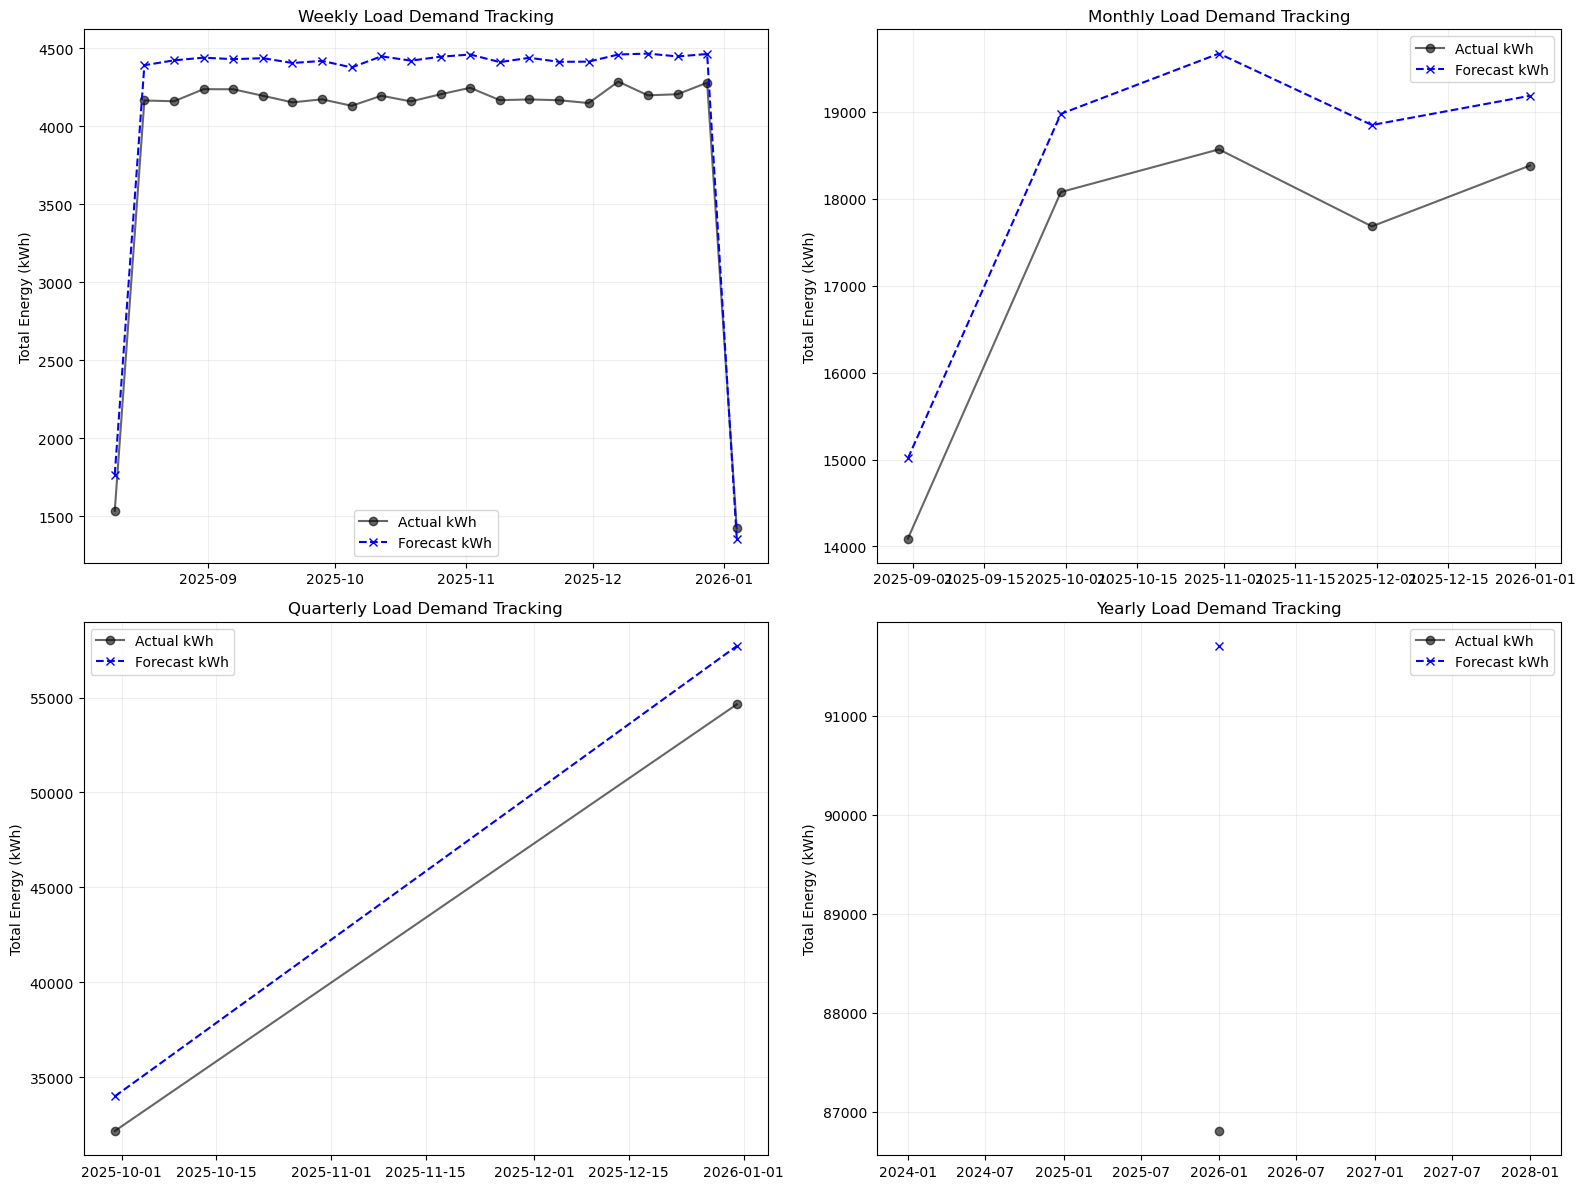

In [9]:
# Timestamps for the test period (aligned with window)
test_timestamps = test_df.index[WINDOW:]
plot_all_scales(final_actuals, final_preds, test_timestamps)